___
# **MRI Inpainting Demo**
## Instructor -- Rizwan Ahmad (ahmad.46@osu.edu)
## BME5710 -- Spring 2026

This notebook demonstrates a minimal PyTorch pipeline for MRI inpainting.
**Optimized for CUDA (A100 / T4) with automatic CPU fallback.**

**What it covers:**
1. Load training images and normalize to float32 in [0, 1]
2. Split into 235 training and 15 validation images
3. Apply a random i.i.d. Bernoulli mask (75% missing pixels) in the data loader
4. Train a UNet with ResBlocks and Attention Gates using a combined L1 + SSIM loss
5. Evaluate each epoch with PSNR and the competition metric: PSNR + 50xSSIM
6. Run inference on masked test images and save a Kaggle-ready submission.csv

**Network input/output:**
- Input: 2-channel tensor -- channel 1 = masked image, channel 2 = binary mask (1=observed, 0=missing)
- Output: 1-channel reconstructed image (float32 in [0, 1])

**Folder structure (relative to this notebook):**
```
project/
  Attempt_optimized.ipynb  <- this notebook
  train/                   <- 250 training TIFFs (train_000.tif ... train_249.tif)
  test-masked/             <- 50 masked TIFFs + 50 binary mask TIFFs
  best_model.pth           <- saved model weights (created by this notebook)
  submission.csv           <- Kaggle submission (created by this notebook)
```

___
### Install dependencies

In [1]:
!pip install numpy pandas matplotlib pillow scikit-image pytorch-msssim torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip


___
### Import libraries

In [2]:
import os
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as skpsnr
from skimage.metrics import structural_similarity as skssim

from pytorch_msssim import ssim
import torch
import torch.nn as nn
from torch.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader

___
### Predefine parameters

In [8]:
train_folder        = "train"          # folder with training TIFFs
test_masked_folder  = "test-masked"    # folder with masked test TIFFs
imag_size           = 256              # image dimensions (H = W)
mask_ratio          = 0.75             # fraction of pixels that are missing
m_tr                = 235              # number of training images
m_val               = 15               # number of validation images
m_te                = 50               # number of test images
batch_size          = 4                # mini-batch size
n_epochs            = 150              # number of training epochs
seed                = 0                # random seed for reproducibility

torch.manual_seed(seed)                # seed PyTorch RNG
np.random.seed(seed)                   # seed NumPy RNG

# AMP (Automatic Mixed Precision) settings
if DEVICE.type == "cuda":
    USE_AMP = True
    AMP_DTYPE = torch.float16
elif DEVICE.type == "mps":
    USE_AMP = False   # MPS AMP is still unstable → disable
    AMP_DTYPE = torch.float16
else:  # CPU
    USE_AMP = False
    AMP_DTYPE = torch.float32

print(f"AMP enabled: {USE_AMP} | dtype: {AMP_DTYPE}")

AMP enabled: False | dtype: torch.float16


___
### Helper functions

In [9]:
def visible_files(folder):
    """Return non-hidden files in a folder (ignores .DS_Store and other dot-files)."""
    return [f for f in os.listdir(folder) if not f.startswith('.')]


def compute_metrics(pred, target):
    """
    Compute PSNR and the competition metric (PSNR + 50xSSIM) averaged over a batch.
    Always runs on CPU in float32 regardless of training precision.
    """
    pred_np   = np.clip(pred.detach().float().cpu().numpy(), 0, 1)  # (B,1,H,W)
    target_np = np.clip(target.detach().float().cpu().numpy(), 0, 1)

    psnr_list, metric_list = [], []
    for i in range(pred_np.shape[0]):
        p = pred_np[i, 0]
        t = target_np[i, 0]
        psnr     = skpsnr(t, p, data_range=1.0)
        ssim_val = skssim(t, p, data_range=1.0)
        psnr_list.append(psnr)
        metric_list.append(psnr + 50.0 * ssim_val)

    return np.mean(psnr_list), np.mean(metric_list)

___
### Load training images

In [10]:
def load_images(folder):
    """
    Load all TIFFs from a folder.
    Returns a list of float32 numpy arrays normalized to [0, 1].
    Handles uint8, uint16, and float source images automatically.
    """
    folder = Path(folder)
    files = sorted([
        f for f in visible_files(folder)
        if f.lower().endswith((".tif", ".tiff"))
        and "_masked" not in f.lower()
        and "_mask" not in f.lower()
    ])
    assert len(files) > 0, f"No training TIFF files found in {folder}"

    images = []
    for fname in files:
        with Image.open(folder / fname) as im:
            img = np.array(im)
        if img.dtype == np.uint16:
            img = img.astype(np.float32) / 65535.0
        elif img.dtype == np.uint8:
            img = img.astype(np.float32) / 255.0
        else:
            img = img.astype(np.float32)
            if img.max() > 1.0:
                img = img / img.max()
        assert img.shape == (imag_size, imag_size), (
            f"Unexpected shape {img.shape} for {fname}; expected ({imag_size}, {imag_size})"
        )
        images.append(img)

    print(f"Loaded {len(images)} training images from '{folder}'")
    return images


all_images = load_images(train_folder)
assert len(all_images) > m_val, f"Need more than m_val={m_val} images; found {len(all_images)}"

if m_tr is None:
    m_tr = len(all_images) - m_val
else:
    assert len(all_images) >= m_tr + m_val, (
        f"Expected at least {m_tr + m_val} images, found {len(all_images)}"
    )

train_images = all_images[:m_tr]
val_images   = all_images[m_tr:m_tr + m_val]
print(f"Split: {len(train_images)} train | {len(val_images)} validation")

Loaded 250 training images from 'train'
Split: 235 train | 15 validation


___
### Dataset and DataLoader

In [11]:
from torch.utils.data import Dataset, DataLoader
import torch
import numpy as np

class InpaintingDataset(Dataset):
    """
    Generates a fresh random Bernoulli mask each time a sample is accessed.

    Returns:
        masked_img : (1, H, W) float32
        mask       : (1, H, W) float32
        full_img   : (1, H, W) float32
    """
    def __init__(self, images, mask_ratio=0.75):
        self.images = images
        self.mask_ratio = mask_ratio

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        full_img = self.images[idx]

        # Ensure numpy float32 in [0, 1]
        if isinstance(full_img, torch.Tensor):
            full_img = full_img.detach().cpu().numpy()

        full_img = full_img.astype(np.float32)

        if full_img.max() > 1.0:
            full_img = full_img / 255.0

        # Fresh random mask every access
        mask = (np.random.rand(*full_img.shape) > self.mask_ratio).astype(np.float32)

        masked_img = full_img * mask

        # Add channel dimension: (H, W) -> (1, H, W)
        full_img   = torch.from_numpy(full_img[None, :, :]).float()
        masked_img = torch.from_numpy(masked_img[None, :, :]).float()
        mask       = torch.from_numpy(mask[None, :, :]).float()

        return masked_img, mask, full_img


train_dataset = InpaintingDataset(train_images, mask_ratio=mask_ratio)
val_dataset   = InpaintingDataset(val_images,   mask_ratio=mask_ratio)

# MPS/CPU-safe DataLoader settings
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f"Train images: {len(train_dataset)} | Val images: {len(val_dataset)}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train images: 235 | Val images: 15
Train batches: 59 | Val batches: 4


___
### UNet model (ResBlocks + Attention Gates)

In [15]:
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        psi = self.relu(self.W_g(g) + self.W_x(x))
        return x * self.psi(psi)


class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1    = nn.Conv2d(in_channels,  out_channels, 3, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_channels)
        self.conv2    = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_channels)
        self.relu     = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + self.shortcut(x))

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = ResBlock(2,   64);  self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ResBlock(64,  128);  self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ResBlock(128,  256); self.pool3 = nn.MaxPool2d(2)
        self.enc4 = ResBlock(256, 512); self.pool4 = nn.MaxPool2d(2)
        # Bottleneck
        self.bottleneck = nn.Sequential(
            ResBlock(512, 1024),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=2, dilation=2, bias=False),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            ResBlock(1024, 1024)
        )
        # Decoder helpers
        def up(cin, cout):
            return nn.Sequential(
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                nn.Conv2d(cin, cout, 3, padding=1)
            )

        # 64→128→256→512→1024
        self.up4 = up(1024, 512); self.dec4 = ResBlock(1024, 512)
        self.up3 = up(512, 256); self.dec3 = ResBlock(512, 256)
        self.up2 = up(256, 128);  self.dec2 = ResBlock(256, 128)
        self.up1 = up(128,  64);  self.dec1 = ResBlock(128,  64)

        # Attention gates
        self.att4 = AttentionGate(512, 512, 256)
        self.att3 = AttentionGate(256, 256, 128)
        self.att2 = AttentionGate(128, 128, 64)
        self.att1 = AttentionGate(64,  64,  32)

        # Output
        self.out_conv = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, masked_img, mask):
        x  = torch.cat([masked_img, mask], dim=1)        # [B, 2, H, W]
        e1 = self.enc1(x);   p1 = self.pool1(e1)
        e2 = self.enc2(p1);  p2 = self.pool2(e2)
        e3 = self.enc3(p2);  p3 = self.pool3(e3)
        e4 = self.enc4(p3);  p4 = self.pool4(e4)
        b  = self.bottleneck(p4)
        u4 = self.up4(b);  d4 = self.dec4(torch.cat([u4, self.att4(u4, e4)], 1))
        u3 = self.up3(d4); d3 = self.dec3(torch.cat([u3, self.att3(u3, e3)], 1))
        u2 = self.up2(d3); d2 = self.dec2(torch.cat([u2, self.att2(u2, e2)], 1))
        u1 = self.up1(d2); d1 = self.dec1(torch.cat([u1, self.att1(u1, e1)], 1))
        return torch.sigmoid(self.out_conv(d1))


model = UNet().to(DEVICE)

# torch.compile gives substantial speedup on CUDA via kernel fusion.
# Skip on CPU -- compilation overhead outweighs benefit for small datasets.
if DEVICE.type == "cuda":
    model = torch.compile(model)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='max',factor=0.5,patience=3)
scaler = GradScaler(enabled=(USE_AMP and AMP_DTYPE == torch.float16))


n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters : {n_params:,}")

Trainable parameters : 64,586,541


___
### Training loop

In [ ]:
l1_loss_fn      = nn.L1Loss()
best_val_metric = -float("inf")

print(f"{'Epoch':>5} | {'Train Loss':>12} | {'Train Metric':>14} | {'Val Loss':>10} | {'Val Metric':>12}")
print("-" * 65)

for epoch in range(1, n_epochs + 1):

    # ── Training ──────────────────────────────────────────────────────────────
    model.train()
    train_loss_sum, train_metric_sum, train_n = 0.0, 0.0, 0

    for masked_img, mask, full_img in train_loader:
        # non_blocking=True overlaps H2D transfer with CPU work when pin_memory=True
        masked_img = masked_img.to(DEVICE, non_blocking=True)
        mask       = mask.to(DEVICE, non_blocking=True)
        full_img   = full_img.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)            # faster than zeroing in-place

        with autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            pred  = model(masked_img, mask)
            recon = mask * masked_img + (1 - mask) * pred
            missing   = 1 - mask
            l1_loss   = torch.mean(torch.abs((recon - full_img) * missing))
            # ssim() requires float32 input -- cast explicitly when using AMP
            ssim_loss = 1 - ssim(recon.float(), full_img.float())
            loss      = 0.45 * l1_loss + 0.55 * ssim_loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = full_img.shape[0]
        _, batch_metric   = compute_metrics(recon, full_img)
        train_loss_sum   += loss.item() * bs
        train_metric_sum += batch_metric * bs
        train_n          += bs

    train_loss   = train_loss_sum   / train_n
    train_metric = train_metric_sum / train_n

    # ── Validation ────────────────────────────────────────────────────────────
    model.eval()
    val_loss_sum, val_metric_sum, val_n = 0.0, 0.0, 0

    with torch.no_grad():
        for masked_img, mask, full_img in val_loader:
            masked_img = masked_img.to(DEVICE, non_blocking=True)
            mask       = mask.to(DEVICE, non_blocking=True)
            full_img   = full_img.to(DEVICE, non_blocking=True)

            with autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
                pred  = model(masked_img, mask)
                recon = mask * masked_img + (1 - mask) * pred
                missing   = 1 - mask
                l1_loss   = torch.mean(torch.abs((recon - full_img) * missing))
                ssim_loss = 1 - ssim(recon.float(), full_img.float())
                loss      = 0.45 * l1_loss + 0.55 * ssim_loss

            bs = full_img.shape[0]
            _, batch_metric  = compute_metrics(recon, full_img)
            val_loss_sum   += loss.item() * bs
            val_metric_sum += batch_metric * bs
            val_n          += bs

    val_loss   = val_loss_sum   / val_n
    val_metric = val_metric_sum / val_n

    print(f"{epoch:>5} | {train_loss:>12.6f} | {train_metric:>14.4f} | {val_loss:>10.6f} | {val_metric:>12.4f}")

    if val_metric > best_val_metric:
        best_val_metric = val_metric
        # Unwrap compiled model before saving so weights load without torch.compile
        save_model = model._orig_mod if hasattr(model, "_orig_mod") else model
        torch.save(save_model.state_dict(), "best_model.pth")
        print("  Saved new best model.")

    scheduler.step(val_metric)

Epoch |   Train Loss |   Train Metric |   Val Loss |   Val Metric
-----------------------------------------------------------------
    1 |     0.017378 |        59.3045 |   0.012880 |      62.6375
  Saved new best model.
    2 |     0.010371 |        68.0718 |   0.009148 |      69.5030
  Saved new best model.


___
### Visualise training / validation samples

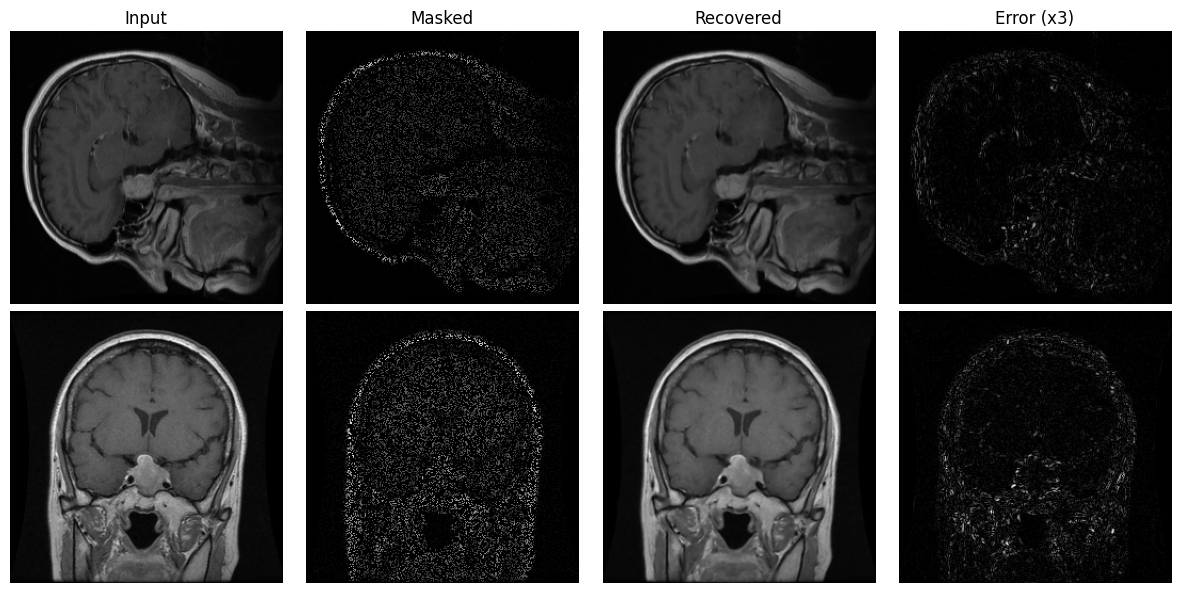

In [ ]:
state = torch.load("best_model.pth", map_location=DEVICE)
(model._orig_mod if hasattr(model, "_orig_mod") else model).load_state_dict(state)
model.eval()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for row, dataset in enumerate([train_dataset, val_dataset]):
    idx = random.randint(0, len(dataset) - 1)
    masked_img, mask, full_img = dataset[idx]

    with torch.no_grad():
        with autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            pred = model(masked_img[None].to(DEVICE), mask[None].to(DEVICE))
        pred      = torch.clamp(pred.float(), 0.0, 1.0)
        recovered = (mask[None].to(DEVICE) * masked_img[None].to(DEVICE)
                     + (1 - mask[None].to(DEVICE)) * pred).cpu()

    orig   = full_img[0].numpy()
    masked = masked_img[0].numpy()
    rec    = recovered[0, 0].numpy()
    err    = np.abs(orig - rec) * 3

    for ax, img, title in zip(axes[row], [orig, masked, rec, err],
                               ["Input", "Masked", "Recovered", "Error (x3)"]):
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        if row == 0:
            ax.set_title(title)
        ax.axis("off")

axes[0, 0].set_ylabel("Train", fontsize=12)
axes[1, 0].set_ylabel("Val",   fontsize=12)
plt.tight_layout()
plt.show()

___
### Run inference on test set

Found 50 masked test images and 50 mask files.


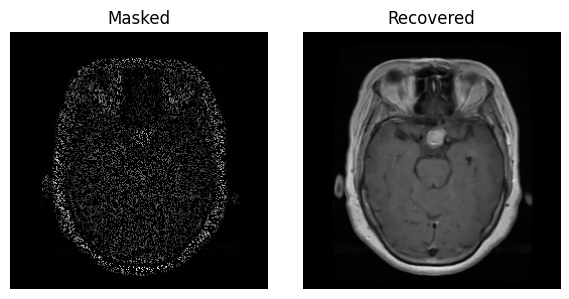

In [ ]:
def load_test_sample(masked_path, mask_path):
    """Load a masked test image and its binary mask. Returns (1,1,H,W) tensors."""
    with Image.open(masked_path) as im:
        masked_img = np.array(im)
    if masked_img.dtype == np.uint16:
        masked_img = masked_img.astype(np.float32) / 65535.0
    elif masked_img.dtype == np.uint8:
        masked_img = masked_img.astype(np.float32) / 255.0
    else:
        masked_img = masked_img.astype(np.float32)
        if masked_img.max() > 1.0:
            masked_img = masked_img / masked_img.max()

    with Image.open(mask_path) as im:
        mask = np.array(im).astype(np.float32)
    if mask.max() > 1.0:
        mask = mask / 255.0
    mask = (mask > 0.5).astype(np.float32)

    return (torch.from_numpy(masked_img[None, None]),
            torch.from_numpy(mask[None, None]))


test_masked_folder = Path(test_masked_folder)
all_test_files = sorted([
    f for f in visible_files(test_masked_folder)
    if f.lower().endswith((".tif", ".tiff"))
])
masked_files = sorted([f for f in all_test_files if f.lower().endswith('_masked.tif') or f.lower().endswith('_masked.tiff')])
mask_files   = sorted([f for f in all_test_files if f.lower().endswith('_mask.tif') or f.lower().endswith('_mask.tiff')])

if m_te is None:
    m_te = len(masked_files)
else:
    assert len(masked_files) == m_te, f"Expected {m_te} masked images, found {len(masked_files)}"
    assert len(mask_files)   == m_te, f"Expected {m_te} mask files, found {len(mask_files)}"

assert len(masked_files) > 0, f"No *_masked.tif files found in {test_masked_folder}"
assert len(masked_files) == len(mask_files), (
    f"Found {len(masked_files)} masked images but {len(mask_files)} masks."
)
print(f"Found {len(masked_files)} masked test images and {len(mask_files)} mask files.")

# Reload best weights
state = torch.load("best_model.pth", map_location=DEVICE)
(model._orig_mod if hasattr(model, "_orig_mod") else model).load_state_dict(state)
model.eval()

reconstructions = []
with torch.no_grad():
    for masked_fname, mask_fname in zip(masked_files, mask_files):
        masked_img, mask = load_test_sample(
            test_masked_folder / masked_fname,
            test_masked_folder / mask_fname
        )
        masked_img = masked_img.to(DEVICE)
        mask       = mask.to(DEVICE)

        with autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            pred = model(masked_img, mask)
        pred  = torch.clamp(pred.float(), 0.0, 1.0)
        recon = mask * masked_img + (1 - mask) * pred
        recon = np.clip(recon.squeeze().cpu().numpy(), 0.0, 1.0)
        reconstructions.append(recon)

# Plot a random test sample
idx = random.randint(0, len(reconstructions) - 1)
with Image.open(test_masked_folder / masked_files[idx]) as im:
    test_masked = np.array(im)
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(test_masked.astype(np.float32), cmap="gray")
axes[0].set_title("Masked"); axes[0].axis("off")
axes[1].imshow(reconstructions[idx], cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Recovered"); axes[1].axis("off")
plt.tight_layout()
plt.show()

___
### Prepare submission.csv for Kaggle

In [ ]:
pixel_cols = [f"pixel_{j}" for j in range(imag_size * imag_size)]
rows       = [rec.ravel() for rec in reconstructions]

submission_df = pd.DataFrame(rows, columns=pixel_cols, dtype=np.float32)
submission_df.insert(0, "id", [f"img_{i:03d}" for i in range(len(reconstructions))])
submission_path = BASE_DIR / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to {submission_path}")
print(f"  Shape : {submission_df.shape}")
print(f"  Range : [{submission_df[pixel_cols].min().min():.4f}, {submission_df[pixel_cols].max().max():.4f}]")

Submission saved to submission.csv
  Shape : (50, 65537)
  Range : [0.0000, 0.9824]
